# "Shapiro says my data is not normal"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/normality-test-trap/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/normality-test-trap/demo.ipynb)

So the analyst abandons the t-test. That move is defended so routinely that it rarely gets
checked, and it rests on two things that are both false.

**First, a normality test is a power curve, not a verdict.** On one fixed population it misses
at n=20 and rejects with near-certainty at n=5,000. The population did not change. Only the
sample size did. "Is my data normal" is not a question the test answers; "do I have enough data
to notice that it is not" is.

**Second, the t-test never asked for normal data.** It asks that the *sampling distribution of
the mean* be close to normal - which the Central Limit Theorem delivers at exactly the sample
sizes where Shapiro becomes unstoppable. The two curves run in opposite directions in n, so the
gate fires hardest precisely where it is least needed.

None of that is an argument here. Every population below is standardised to mean 0, and the null
tested is "the population mean is 0" - so the null is **exactly true in every cell** and every
rejection counted is a false positive by construction.

**What is here**

1. The engine, from the formulas, so this notebook runs standalone
2. Calibration: the one cell where the right answer is known exactly
3. Shapiro-Wilk's rejection rate climbing with n on a fixed population
4. The t-test's error rate on that **same data**, falling with n
5. What the gate actually recommends you switch to, and what that costs
6. The defect the two-sided p-value hides

## 1. The engine

Two procedures and three populations, written out rather than imported. Every population is
standardised using its **population** moments - not the sample's - so the null under test really
is true, rather than true on average.

In [1]:
from __future__ import annotations

import math
from typing import Dict, Tuple

import numpy as np
from scipy import stats

ALPHA = 0.05
BAND_LO, BAND_HI = 0.045, 0.055        # the band a nominal-0.05 test is entitled to sit in
Z99 = 2.5758293035489004


def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """99% Wilson interval on a measured rate. Every verdict below is an interval, not a compare.

    Without this, a 4,000-replicate cell reading 0.043 looks like a broken test when it is a
    coin landing slightly oddly - which is how the first draft of this study managed to flag its
    own exact calibration cell as broken.
    """
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def is_broken(rate: float, reps: int) -> bool:
    """True only when the WHOLE interval clears the band - never on the point estimate alone."""
    lo, hi = wilson(rate, reps)
    return hi < BAND_LO or lo > BAND_HI

SHAPE = {
    "normal": (0.0, 0.0),
    "uniform": (0.0, -1.2),
    "t5": (0.0, 6.0),
    "contaminated": (0.0, 16.9587),
    "lognormal-mild": (1.7502, 5.8984),
    "exponential": (2.0, 6.0),
    "lognormal-strong": (6.1849, 110.9364),
}


def draw(dist: str, n: int, reps: int, rng: np.random.Generator) -> np.ndarray:
    """reps samples of size n, standardised to population mean 0 and sd 1."""
    if dist == "normal":
        return rng.standard_normal((reps, n))
    if dist == "uniform":
        return (rng.random((reps, n)) - 0.5) * np.sqrt(12.0)
    if dist == "t5":
        return rng.standard_t(5, (reps, n)) / np.sqrt(5.0 / 3.0)
    if dist == "contaminated":
        base = rng.standard_normal((reps, n))
        wide = rng.standard_normal((reps, n)) * 5.0
        pick = rng.random((reps, n)) < 0.05
        return np.where(pick, wide, base) / np.sqrt(2.2)
    if dist in ("lognormal-mild", "lognormal-strong"):
        s = 0.5 if dist == "lognormal-mild" else 1.0
        raw = rng.lognormal(0.0, s, (reps, n))
        mean = np.exp(s * s / 2.0)
        sd = np.sqrt((np.exp(s * s) - 1.0) * np.exp(s * s))
        return (raw - mean) / sd
    if dist == "exponential":
        return rng.exponential(1.0, (reps, n)) - 1.0
    raise ValueError(f"unknown distribution: {dist!r}")


def one_sample_t_p(samples: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """One-sample t against mu=0 on every row at once. Returns (t, two-sided p)."""
    n = samples.shape[1]
    mean = samples.mean(axis=1)
    sd = samples.std(axis=1, ddof=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = mean / (sd / np.sqrt(n))
    t = np.where(np.isfinite(t), t, 0.0)
    return t, 2.0 * stats.t.sf(np.abs(t), n - 1)


def shapiro_reject(samples: np.ndarray, alpha: float = ALPHA) -> np.ndarray:
    return np.array([stats.shapiro(r).pvalue < alpha for r in samples])


def wilcoxon_p(samples: np.ndarray) -> np.ndarray:
    out = np.empty(samples.shape[0])
    for i in range(samples.shape[0]):
        try:
            out[i] = stats.wilcoxon(samples[i]).pvalue
        except ValueError:
            out[i] = 1.0
    return out


print("engine ready")

engine ready


And one function that runs both procedures **on the same samples**. That sharing is the whole
point: the conditional procedure picks its test using the very data it then tests, so the
selection and the statistic are correlated. Only a shared-sample simulation can see that.

In [2]:
def measure(dist: str, n: int, reps: int = 4000, alpha: float = ALPHA, seed: int = 0) -> Dict[str, float]:
    """Both procedures, one set of samples, a null that is exactly true."""
    rng = np.random.default_rng(seed)
    x = draw(dist, n, reps, rng)

    sh = shapiro_reject(x, alpha)
    t, tp = one_sample_t_p(x)
    t_rej = tp < alpha
    w_rej = wilcoxon_p(x) < alpha

    return {
        "shapiro_rejects": float(sh.mean()),
        "t_error": float(t_rej.mean()),
        "t_low": float((t_rej & (t < 0)).mean()),
        "t_high": float((t_rej & (t > 0)).mean()),
        "wilcoxon_error": float(w_rej.mean()),
        "gated_error": float(np.where(sh, w_rej, t_rej).mean()),
    }


print("measure() ready - every number below comes out of it")

measure() ready - every number below comes out of it


## 2. Calibration first: the cell where the answer is known

A one-sample t-test on normal data is **exact**. Not approximately right - exactly 0.05. So
before believing anything the harness says about broken tests, make it report the unbroken one
correctly. If this cell does not read ~0.05, nothing after it means anything.

In [3]:
NB_REPS_PREVIEW = 4000   # the calibration cell stays cheap; the study tables below use 20,000
base = measure("normal", 50, reps=NB_REPS_PREVIEW, seed=42)
print("normal data, n=50, null exactly true, nominal alpha = 0.05")
print(f"  Shapiro rejects normality : {base['shapiro_rejects']:.4f}   (should be ~0.05)")
print(f"  t-test false positives    : {base['t_error']:.4f}   (should be ~0.05, exactly)")
print()
spread = [measure("normal", 50, reps=NB_REPS_PREVIEW, seed=900 + i)["t_error"] for i in range(5)]
print(f"  same cell, 5 different seeds: {min(spread):.4f} to {max(spread):.4f}")
print(f"  -> Monte-Carlo noise at 4,000 reps is about +/-{(max(spread) - min(spread)) / 2:.4f}.")
lo_ci, hi_ci = wilson(0.05, NB_REPS_PREVIEW)
print(f"     A 99% interval on a true 0.05 at {NB_REPS_PREVIEW:,} reps is [{lo_ci:.4f}, {hi_ci:.4f}] -")
hi20 = wilson(0.05, 20_000)
print(f"     at 20,000 reps it tightens to [{hi20[0]:.4f}, {hi20[1]:.4f}], which is why the tables")
print("     below pay for 20,000.")
print(f"     'Broken' always means the whole interval clears [{BAND_LO}, {BAND_HI}] -")
print("     never the point estimate on its own.")

normal data, n=50, null exactly true, nominal alpha = 0.05
  Shapiro rejects normality : 0.0520   (should be ~0.05)
  t-test false positives    : 0.0505   (should be ~0.05, exactly)

  same cell, 5 different seeds: 0.0457 to 0.0587
  -> Monte-Carlo noise at 4,000 reps is about +/-0.0065.
     A 99% interval on a true 0.05 at 4,000 reps is [0.0418, 0.0596] -
     at 20,000 reps it tightens to [0.0462, 0.0541], which is why the tables
     below pay for 20,000.
     'Broken' always means the whole interval clears [0.045, 0.055] -
     never the point estimate on its own.


## 3. Shapiro-Wilk is a power curve

One population - a mildly right-skewed lognormal, the shape of almost every revenue, latency and
session-length column anyone has ever analysed. Nothing about it changes below. Only n changes.

In [4]:
NS = [10, 20, 30, 50, 100, 200, 500]
POP = "lognormal-mild"

# 20,000 replicates, matching the full study in evidence.py. At 4,000 this table called cells
# "fine" that the study flags as broken - not because they were fine, but because a 4,000-rep
# interval is too wide to see it. Two artifacts disagreeing about the same cell is worse than
# one slow cell, so the notebook pays the same price the study does. This takes ~60 seconds.
NB_REPS = 20_000

# The seeds are the library grid's own: seed = 1000 * (index of population) + (index of n), with
# the population order in DISTRIBUTIONS and the n order in the full grid. So these rows are not
# "the same study re-run" - they are the SAME CELLS that evidence.txt reports, number for number.
# Without this, a borderline cell lands either side of the threshold on different seeds and the
# notebook and the evidence file disagree about it.
GRID_ORDER = ["normal", "uniform", "t5", "contaminated", "lognormal-mild", "exponential",
              "lognormal-strong"]
GRID_N_ORDER = [10, 20, 30, 50, 100, 200, 500, 1000, 5000]


def grid_seed(dist: str, n: int) -> int:
    return 1000 * GRID_ORDER.index(dist) + GRID_N_ORDER.index(n)


rows = {n: measure(POP, n, reps=NB_REPS, seed=grid_seed(POP, n)) for n in NS}

print(f"population: {POP}   (skew {SHAPE[POP][0]:.2f}) - IDENTICAL in every row")
print(f"{NB_REPS:,} replicates and the same seeds as the full study, so these ARE its cells\n")
print(f"  {'n':>6}  {'Shapiro rejects normality':<28} rate")
for n in NS:
    r = rows[n]["shapiro_rejects"]
    bar = "#" * int(round(r * 26))
    print(f"  {n:>6}  {bar:<28} {r:.3f}")
print()
print("  The population is exactly as non-normal at n=10 as at n=500. The test's CONFIDENCE")
print("  changed, not the data. 'Is it normal' was never the question being answered.")

population: lognormal-mild   (skew 1.75) - IDENTICAL in every row
20,000 replicates and the same seeds as the full study, so these ARE its cells

       n  Shapiro rejects normality    rate
      10  ######                       0.250
      20  ##############               0.521
      30  ###################          0.725
      50  ########################     0.924
     100  ##########################   0.999
     200  ##########################   1.000
     500  ##########################   1.000

  The population is exactly as non-normal at n=10 as at n=500. The test's CONFIDENCE
  changed, not the data. 'Is it normal' was never the question being answered.


## 4. Now the t-test, on that same data

Same samples. Same seeds. The question is no longer "is the data normal" but "does the t-test
still control its false-positive rate at 0.05".

In [5]:
print(f"population: {POP}   null is EXACTLY true, so every rejection is a false positive\n")
print(f"  {'n':>6}  {'Shapiro':>9}  {'t-test':>9}   verdict")
for n in NS:
    r = rows[n]
    ok = not is_broken(r["t_error"], NB_REPS)
    fires = r["shapiro_rejects"] >= 0.50
    if fires and ok:
        v = "FALSE ALARM - gate fires, t-test shows no inflation"
    elif fires and not ok:
        v = "gate is right"
    elif not fires and not ok:
        v = "BLIND SPOT - gate quiet, test broken"
    else:
        v = "agreement"
    print(f"  {n:>6}  {r['shapiro_rejects']:>9.3f}  {r['t_error']:>9.4f}   {v}")
print()
print("  The two columns move in OPPOSITE directions. Shapiro climbs to certainty; the t-test")
print("  converges on nominal, because the CLT is repairing exactly the departure Shapiro is")
print("  getting better at detecting.")

population: lognormal-mild   null is EXACTLY true, so every rejection is a false positive

       n    Shapiro     t-test   verdict
      10      0.250     0.0754   BLIND SPOT - gate quiet, test broken
      20      0.521     0.0675   gate is right
      30      0.725     0.0656   gate is right
      50      0.924     0.0614   gate is right
     100      0.999     0.0546   FALSE ALARM - gate fires, t-test shows no inflation
     200      1.000     0.0556   FALSE ALARM - gate fires, t-test shows no inflation
     500      1.000     0.0505   FALSE ALARM - gate fires, t-test shows no inflation

  The two columns move in OPPOSITE directions. Shapiro climbs to certainty; the t-test
  converges on nominal, because the CLT is repairing exactly the departure Shapiro is
  getting better at detecting.


## 5. What the gate tells you to do instead

"Not normal, so use the non-parametric one" is the second half of the move, and it is where the
real money goes. Wilcoxon signed-rank is not a robust version of the t-test. It tests a different
null: that the distribution is symmetric about zero. A right-skewed variable with **mean exactly
zero** has a **median below zero** - so the null the t-test is testing is true while the null
Wilcoxon is testing is false.

The switch does not make the test more conservative. It changes the question.

In [6]:
print("three procedures, identical data, null on the MEAN is exactly true\n")
print(f"  {'n':>6}  {'t alone':>9}  {'Wilcoxon':>9}  {'Shapiro-gated':>14}")
for n in NS:
    r = rows[n]
    print(f"  {n:>6}  {r['t_error']:>9.4f}  {r['wilcoxon_error']:>9.4f}  {r['gated_error']:>14.4f}")
print()
worst = max(NS, key=lambda n: rows[n]["gated_error"])
w = rows[worst]
print(f"  At n={worst} the gated procedure runs at {w['gated_error']:.4f} where the t-test alone")
print(f"  runs at {w['t_error']:.4f}. That is a {w['gated_error'] / w['t_error']:.0f}x increase in")
print("  false positives, bought by doing the responsible-looking thing.")

three procedures, identical data, null on the MEAN is exactly true

       n    t alone   Wilcoxon   Shapiro-gated
      10     0.0754     0.0722          0.0738
      20     0.0675     0.0932          0.0930
      30     0.0656     0.1179          0.1154
      50     0.0614     0.1577          0.1560
     100     0.0546     0.2483          0.2482
     200     0.0556     0.4456          0.4456
     500     0.0505     0.8138          0.8138

  At n=500 the gated procedure runs at 0.8138 where the t-test alone
  runs at 0.0505. That is a 16x increase in
  false positives, bought by doing the responsible-looking thing.


## 6. The defect the two-sided number hides

Where the t-test *is* affected by skew, the damage is directional. A sample that happens to miss
the long right tail has both a low mean **and** a low variance - and the low variance shrinks the
standard error that the low mean is divided by. The two errors compound instead of cancelling.

So a cell can sit at a perfectly respectable 0.050 two-sided and still be a test that only ever
points one way.

In [7]:
print("exponential population, null exactly true. Each tail should be 0.025.\n")
print(f"  {'n':>6}  {'low':>8}  {'high':>8}  {'two-sided':>11}  {'asymmetry':>10}")
for n in NS:
    r = measure("exponential", n, reps=NB_REPS, seed=grid_seed("exponential", n))
    lo, hi = r["t_low"], r["t_high"]
    asym = max(lo, hi) / min(lo, hi) if min(lo, hi) > 0 else float("inf")
    print(f"  {n:>6}  {lo:>8.4f}  {hi:>8.4f}  {r['t_error']:>11.4f}  {asym:>9.1f}x")

exponential population, null exactly true. Each tail should be 0.025.

       n       low      high    two-sided   asymmetry
      10    0.0961    0.0034       0.0995       28.3x
      20    0.0777    0.0058       0.0835       13.4x
      30    0.0664    0.0076       0.0740        8.7x
      50    0.0607    0.0107       0.0714        5.6x
     100    0.0467    0.0115       0.0583        4.0x
     200    0.0391    0.0151       0.0541        2.6x
     500    0.0360    0.0185       0.0544        1.9x


## 7. The picture

Left: the two curves, running in opposite directions on one fixed population. Right: what the
gate's advice costs when you take it.

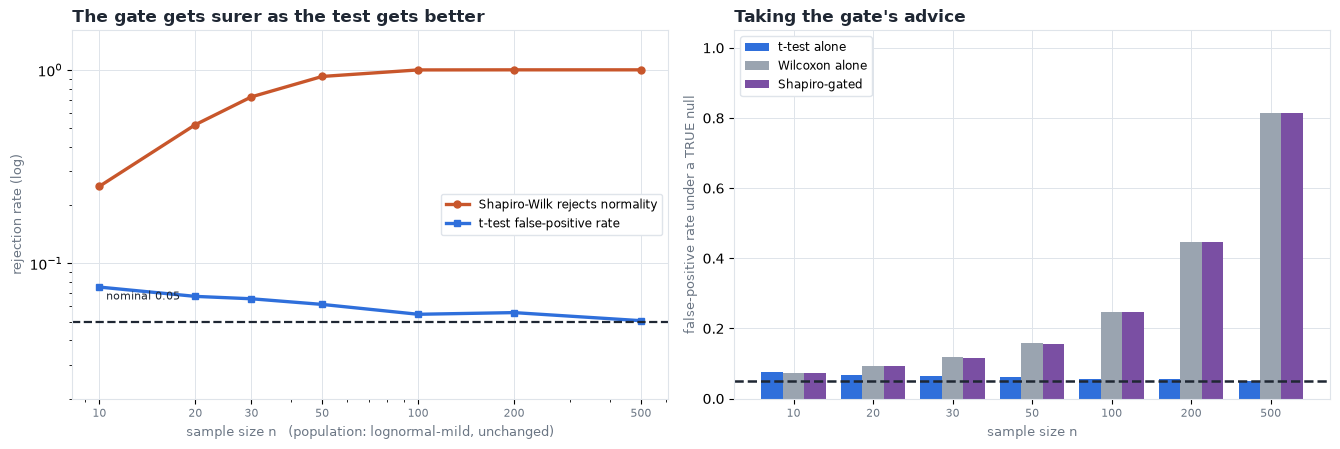

In [8]:
import matplotlib
import matplotlib.pyplot as plt

INK, MUTED, GRID, BG = "#1f2733", "#6b7684", "#dfe4ea", "#ffffff"
SHAPIRO_C, TTEST_C, GATED_C, WILCOXON_C = "#c8562b", "#2f6fdb", "#7a4fa3", "#9aa4b0"

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.6), facecolor=BG)
for ax in (axL, axR):
    ax.set_facecolor(BG)
    ax.grid(True, color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(GRID)

axL.plot(NS, [rows[n]["shapiro_rejects"] for n in NS], "-o", color=SHAPIRO_C, lw=2.4, ms=5,
         label="Shapiro-Wilk rejects normality")
axL.plot(NS, [rows[n]["t_error"] for n in NS], "-s", color=TTEST_C, lw=2.4, ms=5,
         label="t-test false-positive rate")
axL.axhline(ALPHA, color=INK, ls="--", lw=1.6)
axL.text(10.5, ALPHA * 1.3, "nominal 0.05", color=INK, fontsize=8)
axL.set_xscale("log")
axL.set_yscale("log")
axL.set_xticks(NS)
axL.set_xticklabels([str(n) for n in NS], fontsize=8, color=MUTED)
axL.set_ylim(2e-2, 1.6)
axL.set_xlabel(f"sample size n   (population: {POP}, unchanged)", color=MUTED, fontsize=9)
axL.set_ylabel("rejection rate (log)", color=MUTED, fontsize=9)
axL.set_title("The gate gets surer as the test gets better", color=INK, fontsize=12,
              weight="bold", loc="left")
axL.legend(fontsize=8.5, framealpha=1, edgecolor=GRID, loc="center right")

w = 0.27
xs = np.arange(len(NS))
axR.bar(xs - w, [rows[n]["t_error"] for n in NS], width=w, color=TTEST_C, label="t-test alone")
axR.bar(xs, [rows[n]["wilcoxon_error"] for n in NS], width=w, color=WILCOXON_C, label="Wilcoxon alone")
axR.bar(xs + w, [rows[n]["gated_error"] for n in NS], width=w, color=GATED_C, label="Shapiro-gated")
axR.axhline(ALPHA, color=INK, ls="--", lw=1.8)
axR.set_xticks(xs)
axR.set_xticklabels([str(n) for n in NS], fontsize=8, color=MUTED)
axR.set_ylim(0, 1.05)
axR.set_xlabel("sample size n", color=MUTED, fontsize=9)
axR.set_ylabel("false-positive rate under a TRUE null", color=MUTED, fontsize=9)
axR.set_title("Taking the gate's advice", color=INK, fontsize=12, weight="bold", loc="left")
axR.legend(fontsize=8.5, framealpha=1, edgecolor=GRID, loc="upper left")

fig.tight_layout()
plt.savefig("notebook_figure.png", dpi=150, facecolor=BG)
plt.show()

## 8. What the full study found

The notebook above runs 4,000 replicates a cell to stay fast. `evidence.py` runs the same study
at up to 20,000 replicates across 7 populations and 9 sample sizes, and writes `evidence.txt`
and `results.json`. Its findings:

| | |
|---|---|
| **Shapiro scored as a gate on the t-test** | near-zero specificity across the grid: it fires on cell after cell where the t-test's real error rate is already inside `[0.045, 0.055]` |
| **The crossover** | for every skewed population there is an n above which Shapiro rejects the majority of samples *and* the t-test is provably fine. From there up, following the gate is pure cost |
| **The blind spot** | the cells where the t-test really is broken are the small-n cells - exactly where Shapiro has the least power to warn you |
| **The swap is the expensive part** | switching to Wilcoxon on a skewed population takes a correctly-sized test to a false-positive rate approaching 1.0, because Wilcoxon is testing a different null |
| **Symmetric non-normality is harmless** | uniform and t5 populations make Shapiro reject with certainty at large n while the t-test never leaves its band. Tail weight and light tails are not the problem; **skew** is |
| **Two-sided p hides the defect** | under skew the t-test rejects downward far more than upward, and the two-sided rate can look nominal while the test is one-directional |

**The replacement for the gate is not a different test. It is a different question.** Not "is my
data normal" but "at *my* n, with *my* skew, does the procedure I am about to run control its
error rate?" - which is a simulation, and the simulation is twenty lines long. It is the
`measure()` function above.

## 9. Try your own

Change the population and the sample size. The verdict is computed, not asserted.

In [9]:
MY_POP = "lognormal-mild"   # normal | uniform | t5 | contaminated | lognormal-mild | exponential | lognormal-strong
MY_N = 40
MY_ALPHA = 0.05
MY_REPS = 8000   # raise to 20000 to match the study's resolution

r = measure(MY_POP, MY_N, reps=MY_REPS, alpha=MY_ALPHA, seed=7)
fires = r["shapiro_rejects"] >= 0.50
ok = not is_broken(r["t_error"], MY_REPS)
ci = wilson(r["t_error"], MY_REPS)

print(f"{MY_POP}, n={MY_N}, alpha={MY_ALPHA}, {MY_REPS:,} replicates, null exactly true\n")
print(f"  Shapiro rejects normality  {r['shapiro_rejects']:.4f}")
print(f"  t-test false positives     {r['t_error']:.4f}   99% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"  Wilcoxon false positives   {r['wilcoxon_error']:.4f}")
print(f"  Shapiro-gated procedure    {r['gated_error']:.4f}")
print()

if fires and ok:
    print("  FALSE ALARM. The gate fires, the t-test is fine. Following it costs")
    print(f"  {r['gated_error'] / r['t_error']:.1f}x the false positives and buys nothing.")
elif fires and not ok:
    print("  The gate is right that something is off - but check the swap it recommends.")
elif not fires and not ok:
    print("  BLIND SPOT. The gate would have waved this through, and the t-test is off.")
else:
    print("  Agreement: gate quiet, t-test inside its band.")

# Want to see how bad the tails get? Uncomment:
# print(f"low {r['t_low']:.4f} vs high {r['t_high']:.4f}")

lognormal-mild, n=40, alpha=0.05, 8,000 replicates, null exactly true

  Shapiro rejects normality  0.8565
  t-test false positives     0.0635   99% CI [0.0568, 0.0709]
  Wilcoxon false positives   0.1371
  Shapiro-gated procedure    0.1346

  The gate is right that something is off - but check the swap it recommends.


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/normality-test-trap)

The same study runs as a Streamlit app where you can drag the design around instead of editing
constants:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number quoted here into `evidence.txt` and `results.json`, and
`pytest` asserts the findings so a library change that breaks one of them fails the suite.